# Feature Selection Demonstration In Python

## Background

In customer-centric marketing, organizations often run targeted campaigns to improve engagement and conversion rates. With the availability of granular transactional data at the SKU level, it becomes possible to model customer purchase behavior in greater detail. However, such high-dimensional data introduces challenges related to redundancy, multicollinearity, and model interpretability. Feature selection therefore plays a crucial role in building robust and efficient predictive models for campaign response.

## Objective
The objective of this analysis is to select the most important SKU-level features that help predict customer response to a marketing campaign, while reducing the overall number of variables and keeping model performance stable and interpretable.

## Data Description

The dataset consists of customer-level transactional information aggregated at the SKU level. Each observation represents a unique customer, with features capturing the transaction amount over the past 12 months for approximately 300 different SKUs. The target variable is a binary campaign response indicator, denoting whether a customer responded to the marketing campaign.


**Feature Selection Methods Used:**
Three feature selection approaches were explored in this analysis: 
1. correlation-based feature elimination
2. Recursive Feature Elimination (RFE)
3. Recursive Feature Elimination with Cross-Validation (RFECV)

to identify the most relevant SKU-level predictors for campaign response modeling.


### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings("ignore")


### Import Data

In [2]:
df = pd.read_csv('Retail Campaign Data.csv')
df.head()

,custid,SKU_238_txn_amount_12m,SKU_183_txn_amount_12m,SKU_084_txn_amount_12m,SKU_088_txn_amount_12m,SKU_042_txn_amount_12m,SKU_225_txn_amount_12m,SKU_004_txn_amount_12m,SKU_101_txn_amount_12m,SKU_090_txn_amount_12m,...,SKU_189_txn_amount_12m,SKU_100_txn_amount_12m,SKU_249_txn_amount_12m,SKU_177_txn_amount_12m,SKU_277_txn_amount_12m,SKU_151_txn_amount_12m,SKU_020_txn_amount_12m,SKU_078_txn_amount_12m,SKU_251_txn_amount_12m,Campaign_Response
0,1,0.618189,1.238310,1.276956,0.170110,1.043439,0.862283,-0.332396,-0.194911,-13.114700,...,-0.083414,6.859705,-1.247314,0.624103,0.175272,-0.808966,-0.407116,-0.839233,1.796245,0
1,2,-0.546363,-0.808548,-0.184320,-1.686017,0.946010,0.620847,0.628681,0.319284,-0.883747,...,-0.420260,-7.898538,-0.664805,-0.831049,0.607828,-0.305192,0.851964,0.971612,-0.268303,1
2,3,-0.231725,-0.144679,-2.288798,-0.038994,1.424535,-0.359090,0.169255,0.397480,-7.156511,...,1.033475,-1.242203,0.327033,0.198252,-0.340939,0.176528,-1.727613,-1.134733,-0.039627,0
3,4,0.357387,-1.080031,-0.237522,0.207558,0.439681,-0.021442,-0.080540,-1.163383,-5.079330,...,-0.274779,2.837640,1.587606,-0.547697,0.396078,1.721224,-1.085538,1.313102,0.251677,0
4,5,0.585520,-0.588289,0.355790,-1.974041,-0.463407,-0.347682,-0.547494,-2.374378,-15.003925,...,-2.053939,-4.077566,-0.176653,-0.903068,0.346423,2.904060,0.124699,0.432898,0.216859,1


### Split Data Into Train & Test

In [3]:

# Separate features and target
X = df.drop(columns=['custid', 'Campaign_Response'])
y = df['Campaign_Response']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y   # IMPORTANT if response is imbalanced
)


## Method 1 :  Correlation-Based Feature Elimination

In [4]:
# Absolute correlation matrix
corr_matrix = X_train.corr().abs()

threshold = 0.9

# Upper triangle matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


to_drop = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

print(f"Features before correlation filter: {X_train.shape[1]}")
print(f"Features to drop: {len(to_drop)}")


Features before correlation filter: 300
Features to drop: 0


### Inference :
Correlation-based feature selection was not effective because the standardized SKU features showed weak pairwise linear correlations, making the method unable to meaningfully reduce dimensionality.

## Method 2 : RFE

Recursive Feature Elimination (RFE) is a wrapper-based feature selection method that repeatedly fits a model and removes the least important features based on model coefficients or feature importance.
**This process continues until a predefined number of features remains, resulting in a reduced and more relevant feature set.**

### a. Choose a Base Model for RFE

**Note :**
The penalty 'l2' shrinks coeffs towards 0 without setting them exactly to 0 (Ridge Regression)

In [5]:
base_model = LogisticRegression(
    penalty='l2', 
    solver='liblinear',
    max_iter=1000
)

### b. Apply RFE
Decide how many features to keep

Start with something reasonable, e.g. 10%-20% SKU'S

In [6]:

rfe = RFE(
    estimator=base_model,
    n_features_to_select=30, #Selecting 10% of total feature set
    step=10      # remove 10 features per iteration (faster)
)

rfe.fit(X_train, y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...r='liblinear')
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",30
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",10
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


####  Note :
In this analysis, n_features_to_select is set to 30, corresponding to approximately 10% of the total feature set.

### c. Extract Selected Features


In [7]:

selected_features = X_train.columns[rfe.support_]

print("Selected SKU features:")
print(selected_features.tolist())

print("No. of features selected :")
print(len(selected_features))



Selected SKU features:
['SKU_081_txn_amount_12m', 'SKU_220_txn_amount_12m', 'SKU_035_txn_amount_12m', 'SKU_227_txn_amount_12m', 'SKU_222_txn_amount_12m', 'SKU_130_txn_amount_12m', 'SKU_148_txn_amount_12m', 'SKU_154_txn_amount_12m', 'SKU_210_txn_amount_12m', 'SKU_299_txn_amount_12m', 'SKU_164_txn_amount_12m', 'SKU_106_txn_amount_12m', 'SKU_296_txn_amount_12m', 'SKU_134_txn_amount_12m', 'SKU_258_txn_amount_12m', 'SKU_136_txn_amount_12m', 'SKU_095_txn_amount_12m', 'SKU_204_txn_amount_12m', 'SKU_121_txn_amount_12m', 'SKU_233_txn_amount_12m', 'SKU_182_txn_amount_12m', 'SKU_028_txn_amount_12m', 'SKU_255_txn_amount_12m', 'SKU_174_txn_amount_12m', 'SKU_192_txn_amount_12m', 'SKU_040_txn_amount_12m', 'SKU_240_txn_amount_12m', 'SKU_026_txn_amount_12m', 'SKU_020_txn_amount_12m', 'SKU_078_txn_amount_12m']
No. of features selected :
30


### d. Fit Final Model

In [8]:
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

final_model = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=1000
)

final_model.fit(X_train_rfe, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

### e. Plot RFE Ranking Distribution

Rank = 1 → selected features

Rank > 1 → eliminated earlier

Larger rank → removed sooner

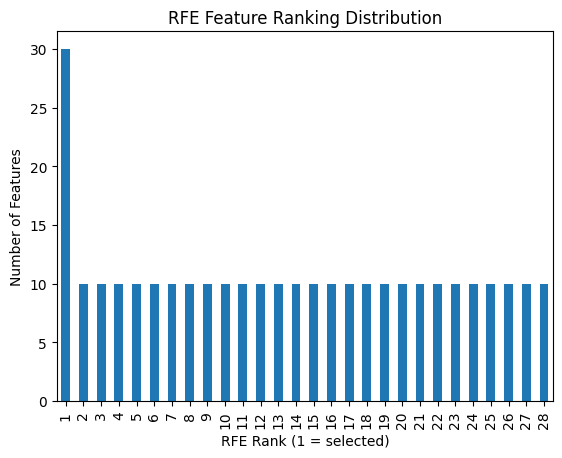

In [9]:
rfe_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfe.ranking_
}).sort_values('rank')

rfe_ranking['rank'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("RFE Rank (1 = selected)")
plt.ylabel("Number of Features")
plt.title("RFE Feature Ranking Distribution")
plt.show()


### f. Coefficients of Final Selected Features

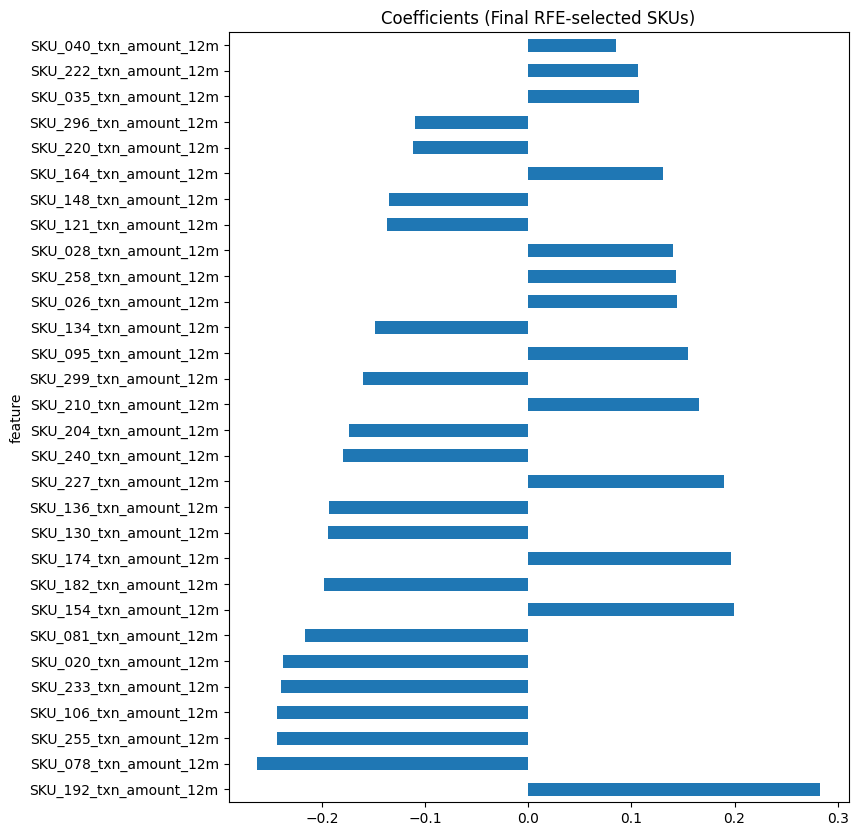

In [10]:
final_model = rfe.estimator_

coef_df = pd.DataFrame({
    'feature': X_train.columns[rfe.support_],
    'coefficient': final_model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)


coef_df.set_index('feature')['coefficient'].plot(
    kind='barh',
    figsize=(8, 10)
)
plt.title("Coefficients (Final RFE-selected SKUs)")
plt.show()


### g. Performance Check

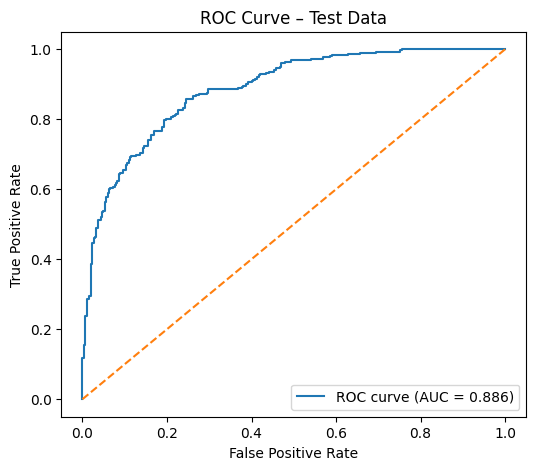

In [11]:
# Predicted probabilities
y_pred_proba = final_model.predict_proba(X_test_rfe)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Test Data")
plt.legend(loc="lower right")
plt.show()


## Method 3 : RFECV

**RFECV (Recursive Feature Elimination with Cross-Validation)** is an extension of RFE that automatically determines the optimal number of features by evaluating model performance using cross-validation.
It recursively removes features and selects the subset that gives the best cross-validated score.


### a. Apply RFECV

In [12]:
base_model = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=1000
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


rfecv = RFECV(
    estimator=base_model,
    step=10,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1   
)
rfecv.fit(X_train, y_train)



,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegre...r='liblinear')
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",10
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'roc_auc'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a posit

### b. Get Optimal No. of features

In [13]:
print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 40


### c. Visualize Model Performance vs Number of Selected Features (RFECV)

In [14]:
 range(1, len(rfecv.cv_results_['mean_test_score']) + 1)

range(1, 32)

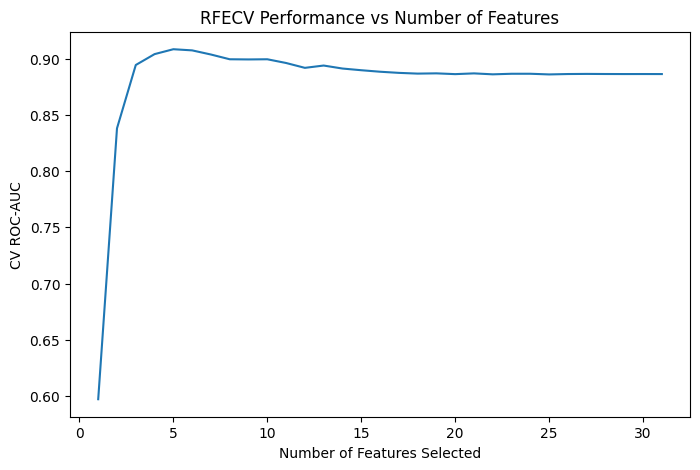

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score']
)
plt.xlabel("Number of Features Selected")
plt.ylabel("CV ROC-AUC")
plt.title("RFECV Performance vs Number of Features")
plt.show()


### Inference :
The RFECV curve shows that the cross-validated ROC-AUC stabilizes around **20 features**, with no significant performance gain beyond this point. Hence, selecting **20 features** provides an optimal balance between model performance and complexity.


### d. Performance Check :  Test AUC

In [16]:
# Transform test data using RFECV-selected features
X_test_rfecv = rfecv.transform(X_test)

# Fit final model on full training data
final_model = rfecv.estimator_
final_model.fit(rfecv.transform(X_train), y_train)

# Test AUC
y_test_proba = final_model.predict_proba(X_test_rfecv)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test AUC (RFECV selected features):", test_auc)


Test AUC (RFECV selected features): 0.9158184808213697
